c:\Users\pabli\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\pabli\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


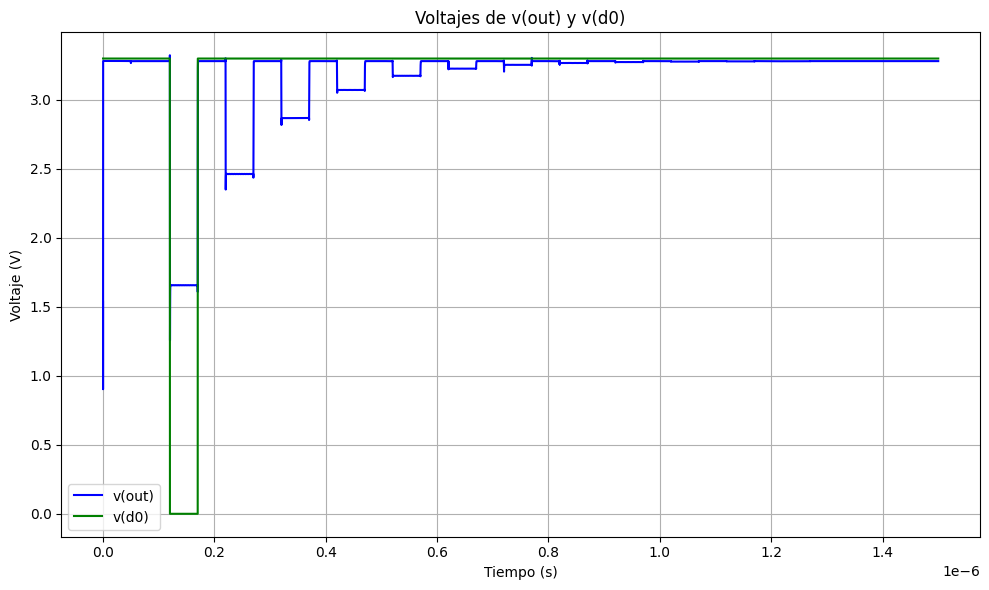

In [ ]:
from spyci import spyci
import matplotlib.pyplot as plt

# IMPORTANTE!!!!!!!!!!!!!!!!!!!!!!!
#MODIFICAR LA LIBRERIA np.complex_ por np.complex128

# Ruta al archivo RAW generado por la simulación
ruta_archivo = r"./../sim/dac_output.raw"

# Cargar datos con spyci
data = spyci.load_raw(ruta_archivo)

# Mostrar variables disponibles (nombre exacto de nodos, etc.)
#print("Variables disponibles:", data['vars'])

# Ver los primeros datos crudos
#print("Datos disponibles:", list(data['values'].keys()))

# Extraer tiempo y voltaje (ajustar 'v(out)' según lo que imprima arriba)
tiempo = data['values']['time']
vout = data['values']['v(out)']
vd0 = data['values']['v(d0)']

if vout is None:
    raise ValueError("No se encontró 'v(out)' en los datos. Revisa los nombres impresos.")

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(tiempo, vout, label="v(out)", color='blue')
plt.plot(tiempo, vd0, label="v(d0)", color='green')
plt.xlabel("Tiempo (s)")
plt.ylabel("Voltaje (V)")
plt.title("Voltajes de v(out) y v(d0)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


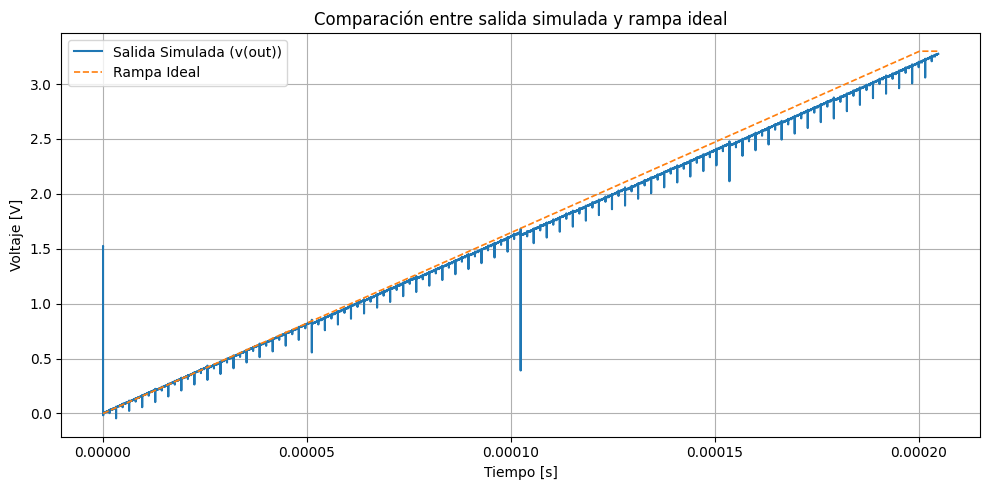

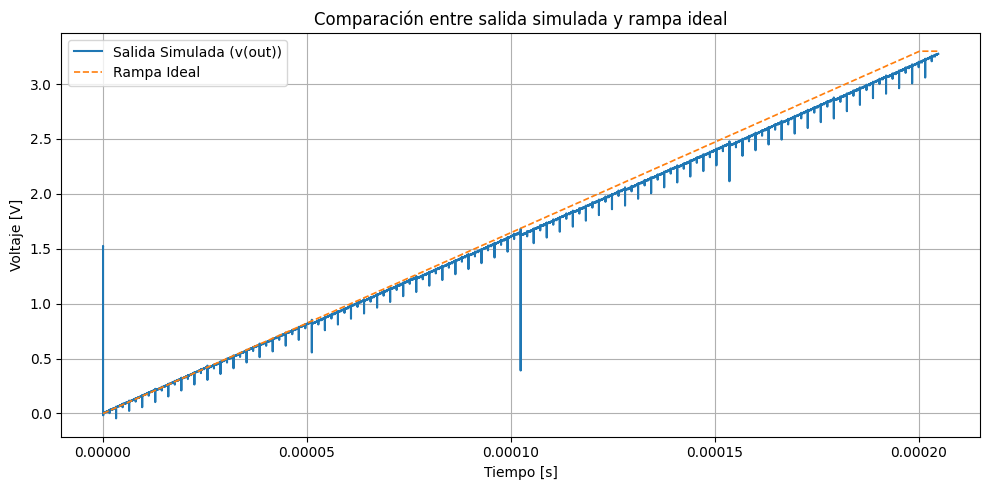

In [23]:
from spyci import spyci
import matplotlib.pyplot as plt
import numpy as np

# Cargar datos del archivo .raw
ruta_archivo = r"./../sim/dac_out_ramp.raw"
data = spyci.load_raw(ruta_archivo)

# Extraer datos de tiempo y salida del DAC
tiempo = np.array(data['values']['time'])
vout = np.array(data['values']['v(out)'])

def generar_rampa_ideal_alineada(vref, nbits, tiempo):
    """
    Genera una rampa de salida ideal para un DAC tipo CDAC,
    alineada con el vector de tiempo de la simulación.

    Parámetros:
    - vref: tensión de referencia del DAC
    - nbits: cantidad de bits del DAC
    - tiempo: array de tiempos extraído del archivo .raw

    Retorna:
    - Array de voltajes de la rampa ideal alineada con 'tiempo'
    """
    niveles = 2 ** nbits
    lsb = vref / niveles
    rampa = np.arange(niveles) * lsb

    # Determinar cuántos pasos de DAC caben en la duración de la simulación
    pasos_totales = len(tiempo)
    repeticiones_por_paso = pasos_totales // niveles

    # Repetir cada valor de la rampa para cubrir el tiempo simulado
    rampa_expandida = np.repeat(rampa, repeticiones_por_paso)

    # Si sobran muestras, extender con el último valor
    faltantes = pasos_totales - len(rampa_expandida)
    if faltantes > 0:
        rampa_expandida = np.concatenate([rampa_expandida, np.full(faltantes, rampa[-1])])

    return rampa_expandida

# Parámetros del DAC
vref = 3.3  # Voltaje de referencia
nbits = 12   # Número de bits del DAC

# Generar rampa ideal alineada
rampa_ideal = generar_rampa_ideal_alineada(vref, nbits, tiempo)

# Graficar comparación
plt.figure(figsize=(10, 5))
plt.plot(tiempo, vout, label="Salida Simulada (v(out))", lw=1.5)
plt.plot(tiempo, rampa_ideal, '--', label="Rampa Ideal", lw=1.2)
plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje [V]")
plt.title("Comparación entre salida simulada y rampa ideal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(tiempo, vout, label="Salida Simulada (v(out))", lw=1.5)
plt.plot(tiempo, rampa_ideal, '--', label="Rampa Ideal", lw=1.2)
plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje [V]")
plt.title("Comparación entre salida simulada y rampa ideal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


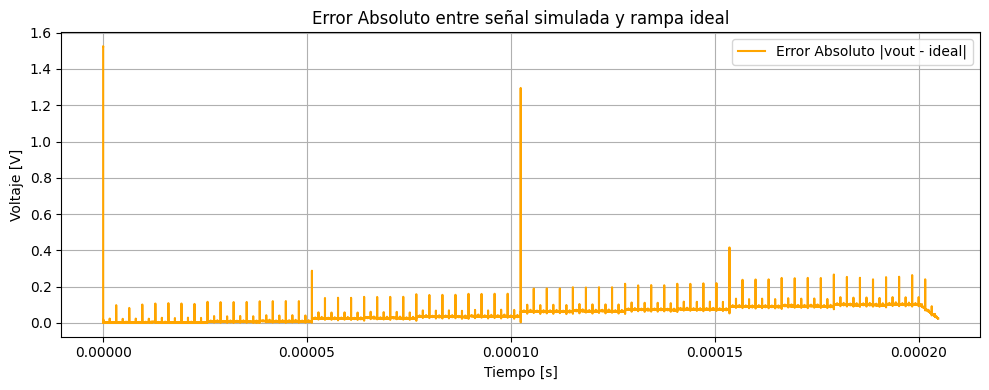

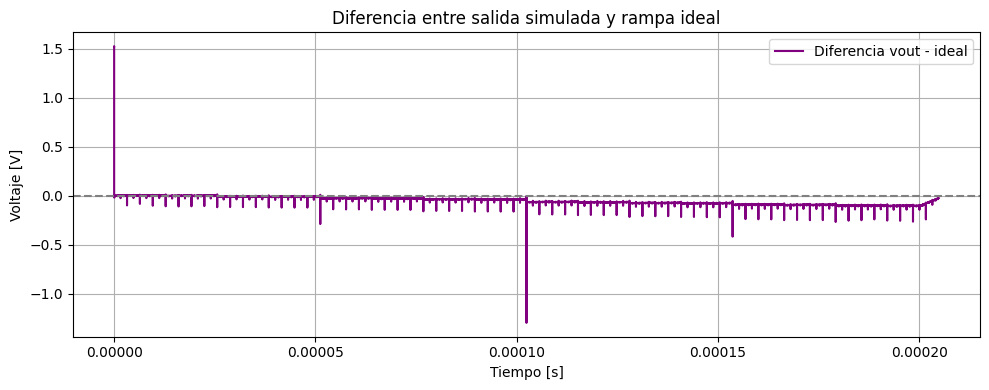

In [24]:
# Calcular error absoluto y diferencia punto a punto
error_absoluto = np.abs(vout - rampa_ideal)
diferencia = vout - rampa_ideal  # Puede ser positiva o negativa

# Graficar error absoluto
plt.figure(figsize=(10, 4))
plt.plot(tiempo, error_absoluto, label="Error Absoluto |vout - ideal|", color='orange')
plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje [V]")
plt.title("Error Absoluto entre señal simulada y rampa ideal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Graficar diferencia (útil para DNL visual)
plt.figure(figsize=(10, 4))
plt.plot(tiempo, diferencia, label="Diferencia vout - ideal", color='purple')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje [V]")
plt.title("Diferencia entre salida simulada y rampa ideal")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\pabli\AppData\Local\Temp\ipykernel_10028\1470808600.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  niveles_vout[idx] += vout[i]


LSB: 0.0008 V
Máximo DNL: 370.7882 LSB
Mínimo DNL: -1022.5971 LSB
Máximo INL: 0.8195 V
Mínimo INL: -0.3629 V
Error RMS: 0.063000+0.000000j V
PSNR: 34.38+0.00j dB


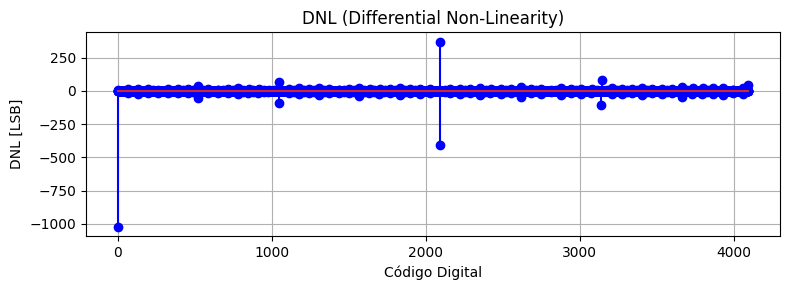

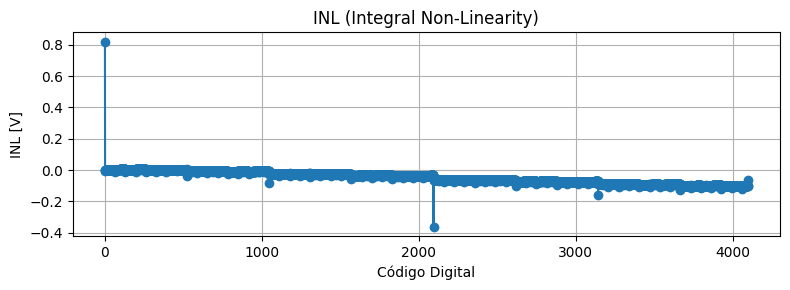

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def analizar_dac(vout, rampa_ideal, vref, nbits):
    niveles = 2**nbits
    lsb = vref / niveles

    # Redondear la salida simulada a niveles de cuantización
    indices_ideales = np.round(rampa_ideal / lsb).astype(int)
    indices_ideales = np.clip(indices_ideales, 0, niveles - 1)

    # Promediar el valor de salida para cada código digital
    niveles_vout = np.zeros(niveles)
    cuentas = np.zeros(niveles)

    for i, idx in enumerate(indices_ideales):
        niveles_vout[idx] += vout[i]
        cuentas[idx] += 1

    with np.errstate(divide='ignore', invalid='ignore'):
        niveles_vout = np.divide(niveles_vout, cuentas, where=cuentas > 0)

    # Recalcular ideal por nivel
    ideal_por_nivel = np.arange(niveles) * lsb

    # Calcular DNL e INL
    diferencias = np.diff(niveles_vout)
    dnl = (diferencias / lsb) - 1
    inl = niveles_vout - ideal_por_nivel

    # Rellenar NaNs con interpolación si es necesario
    inl = np.nan_to_num(inl, nan=0.0)
    dnl = np.nan_to_num(dnl, nan=0.0)

    # Error absoluto y RMS
    error_abs = np.abs(vout - rampa_ideal)
    error_rms = np.sqrt(np.mean((vout - rampa_ideal)**2))

    # PSNR
    valor_pico = np.max(rampa_ideal)
    psnr = 20 * np.log10(valor_pico / error_rms) if error_rms != 0 else np.inf

    # Mostrar resultados
    print(f"LSB: {lsb:.4f} V")
    print(f"Máximo DNL: {np.max(dnl):.4f} LSB")
    print(f"Mínimo DNL: {np.min(dnl):.4f} LSB")
    print(f"Máximo INL: {np.max(inl):.4f} V")
    print(f"Mínimo INL: {np.min(inl):.4f} V")
    print(f"Error RMS: {error_rms:.6f} V")
    print(f"PSNR: {psnr:.2f} dB")

    # Graficar DNL (versión con ejes y colores personalizados)
    plt.figure(figsize=(8, 3))
    markerline, stemlines, baseline = plt.stem(dnl)
    plt.setp(markerline, marker='o', color='blue')
    plt.setp(stemlines, color='blue')
    plt.title("DNL (Differential Non-Linearity)")
    plt.xlabel("Código Digital")
    plt.ylabel("DNL [LSB]")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Graficar INL
    plt.figure(figsize=(8, 3))
    plt.plot(inl, marker='o')
    plt.title("INL (Integral Non-Linearity)")
    plt.xlabel("Código Digital")
    plt.ylabel("INL [V]")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Llamar a la función con tus datos
analizar_dac(vout, rampa_ideal, vref, nbits)


In [33]:
def analizar_dac_con_settling(vout, rampa_ideal, tiempo, vref, nbits, porcentaje_estable=0.05):
    niveles = 2**nbits
    lsb = vref / niveles

    # Identificar el código ideal por muestra
    codigos_ideales = np.round(rampa_ideal / lsb).astype(int)
    codigos_ideales = np.clip(codigos_ideales, 0, niveles - 1)

    niveles_vout = np.full(niveles, np.nan)
    
    for nivel in range(niveles):
        idx = np.where(codigos_ideales == nivel)[0]
        if len(idx) == 0:
            continue

        # Detectar cuándo empieza el código y su duración
        t_inicio = tiempo[idx[0]]
        t_fin = tiempo[idx[-1]]
        t_estable = t_inicio + (1 - porcentaje_estable) * (t_fin - t_inicio)

        # Filtrar solo los datos "estables"
        idx_estables = idx[tiempo[idx] >= t_estable]

        if len(idx_estables) > 0:
            niveles_vout[nivel] = np.mean(vout[idx_estables])

    # Ideal por nivel
    ideal_por_nivel = np.arange(niveles) * lsb

    # Calcular DNL e INL
    diferencias = np.diff(niveles_vout)
    dnl = (diferencias / lsb) - 1
    inl = niveles_vout - ideal_por_nivel

    dnl = np.nan_to_num(dnl)
    inl = np.nan_to_num(inl)

    # Error RMS y PSNR (usando valores válidos)
    vout_estimado = niveles_vout[codigos_ideales]
    vout_estimado = np.nan_to_num(vout_estimado, nan=0)
    error_rms = np.sqrt(np.mean((vout_estimado - rampa_ideal)**2))
    psnr = 20 * np.log10(np.max(rampa_ideal) / error_rms) if error_rms > 0 else np.inf

    # Resultados
    print(f"LSB: {lsb:.4f} V")
    print(f"Máximo DNL: {np.max(dnl):.4f} LSB")
    print(f"Mínimo DNL: {np.min(dnl):.4f} LSB")
    print(f"Máximo INL: {np.max(inl):.4f} V")
    print(f"Mínimo INL: {np.min(inl):.4f} V")
    print(f"Error RMS: {error_rms:.6f} V")
    print(f"PSNR: {psnr:.2f} dB")

    # Graficar DNL
    plt.figure(figsize=(8, 3))
    plt.stem(dnl)
    plt.title("DNL (Differential Non-Linearity)")
    plt.xlabel("Código Digital")
    plt.ylabel("DNL [LSB]")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Graficar INL
    plt.figure(figsize=(8, 3))
    plt.plot(inl, marker='o')
    plt.title("INL (Integral Non-Linearity)")
    plt.xlabel("Código Digital")
    plt.ylabel("INL [V]")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


C:\Users\pabli\AppData\Local\Temp\ipykernel_10028\544250518.py:25: ComplexWarning: Casting complex values to real discards the imaginary part
  niveles_vout[nivel] = np.mean(vout[idx_estables])


LSB: 0.0008 V
Máximo DNL: 94.0824 LSB
Mínimo DNL: -52.4340 LSB
Máximo INL: 0.0059 V
Mínimo INL: -0.1316 V
Error RMS: 0.058982 V
PSNR: 34.95 dB


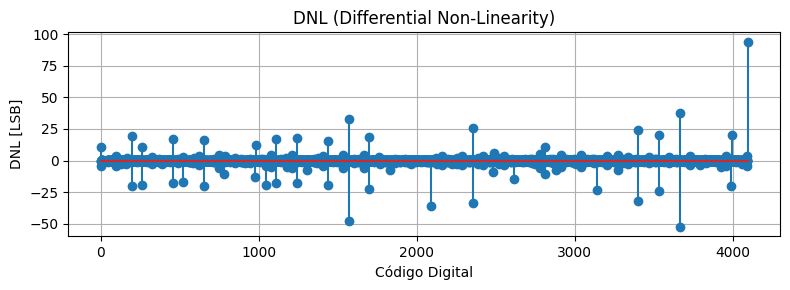

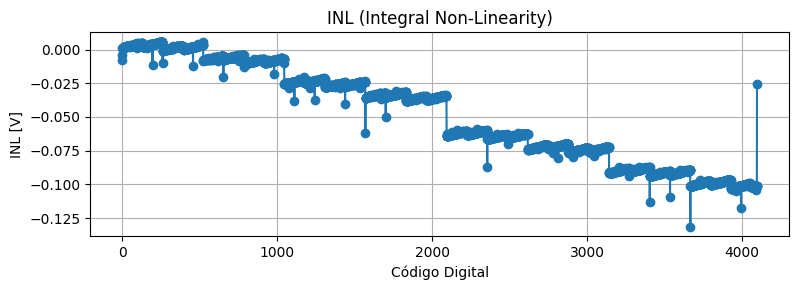

In [34]:
analizar_dac_con_settling(vout, rampa_ideal, tiempo, vref, nbits)
